# **Comportamiento del Oro Frente al S&P 500 Durante Crisis**

#### **Hipótesis:** Existe una correlación negativa en momentos de alta incertidumbre mundial. Se espera poder observar que en marzo del 2020, mientras las acciones caían de manera brusca, el oro mantuvo su valor o subió más rápido en la recuperación, actuando como un activo refugio.

1. _Primero instalamos la librería **yfinance**_

In [1]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2. _Descargamos y limpiamos los datos (eliminar los nulos si es que existen). También analizamos TODAS las filas de golpe, ya que nos interesan los mínimos, máximos y la desviación estándar_

In [2]:
import yfinance as yf
import pandas as pd

data = yf.download(['SPY', 'GLD'], start = "2019-01-01", end = "2026-03-01")['Close']

df = data.dropna().reset_index()

print(f"\nDimensiones: {df.shape}")
print("\nConteo de Nulos: ")
print(df.isnull().sum())

df.describe()

[*********************100%***********************]  2 of 2 completed


Dimensiones: (1799, 3)

Conteo de Nulos: 
Ticker
Date    0
GLD     0
SPY     0
dtype: int64


Ticker,Date,GLD,SPY
count,1799,1799.000000,1799.000000
mean,2022-07-29 04:18:32.618121216,198.820083,420.291270
min,2019-01-02 00:00:00,119.940002,204.944855
25%,2020-10-13 12:00:00,162.340004,318.566849
50%,2022-07-28 00:00:00,175.660004,401.185577
75%,2024-05-11 12:00:00,215.570007,508.289795
max,2026-02-27 00:00:00,495.899994,693.595764
std,NaN,69.894104,123.539873


3. _Realizamos un análisis de correlación (Cercano a -1: la hipótesis es correcta. Cercano a 1: Se mueven igual y la hipótesis falla)_

In [3]:
# Relación entre SYP y GLD

df[['SPY', 'GLD']].corr()

Ticker,SPY,GLD
Ticker,,
SPY,1.000000,0.891403
GLD,0.891403,1.000000


4. _Para responder preguntas más específicas creamos un filtro para el año 2020._

In [4]:
# Fechas específicas (Pandemia)

marzo_2020 = df[(df['Date'] >= '2020-03-01') & (df['Date'] <= '2020-03-31')]
display(marzo_2020)

Ticker,Date,GLD,SPY
292,2020-03-02,149.199997,282.467377
293,2020-03-03,153.889999,274.379608
294,2020-03-04,154.160004,285.912598
295,2020-03-05,157.490005,276.408386
296,2020-03-06,157.550003,271.839142
297,2020-03-09,157.809998,250.609863
298,2020-03-10,154.479996,263.577698
299,2020-03-11,153.929993,250.728745
300,2020-03-12,147.789993,226.739700
301,2020-03-13,143.279999,246.122833


### **Gráficos**

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

**Gráfico 1**

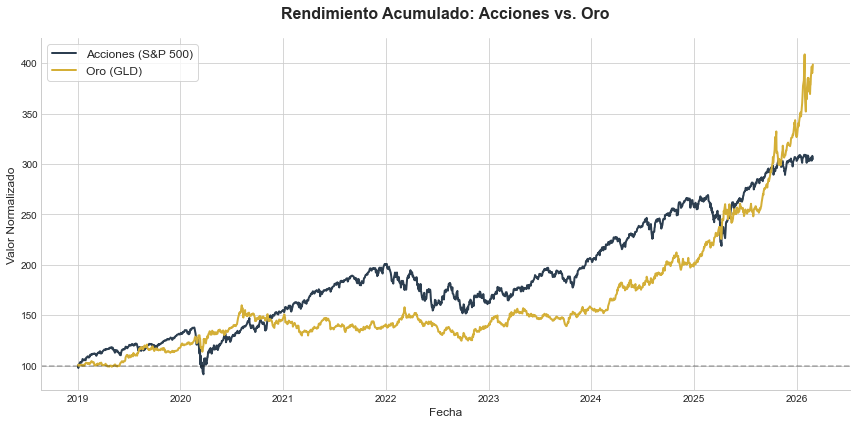

In [ ]:
plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(12, 6))

plt.plot(df['Date'], df_norm['SPY'], label = 'Acciones (S&P 500)', color = '#2c3e50', linewidth = 2)
plt.plot(df['Date'], df_norm['GLD'], label = 'Oro (GLD)', color = '#d4af37', linewidth = 2)
plt.axhline(100, color = 'black', linestyle = '--', alpha = 0.3)
plt.title('Rendimiento Acumulado: Acciones vs. Oro', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Fecha', fontsize = 12)
plt.ylabel('Valor Normalizado', fontsize = 12)
plt.legend(frameon = True, fontsize = 12, loc = 'upper left')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


_Calculamos los retornos diarios:_ 
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

In [9]:
df_retornos = df.set_index('Date')[['SPY', 'GLD']].pct_change().dropna()
df_retornos['Year'] = df_retornos.index.year

**Gráfico 2**

C:\Users\isido\AppData\Local\Temp\ipykernel_24468\804450106.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = 'Year', y = 'SPY', data = df_retornos.reset_index(),


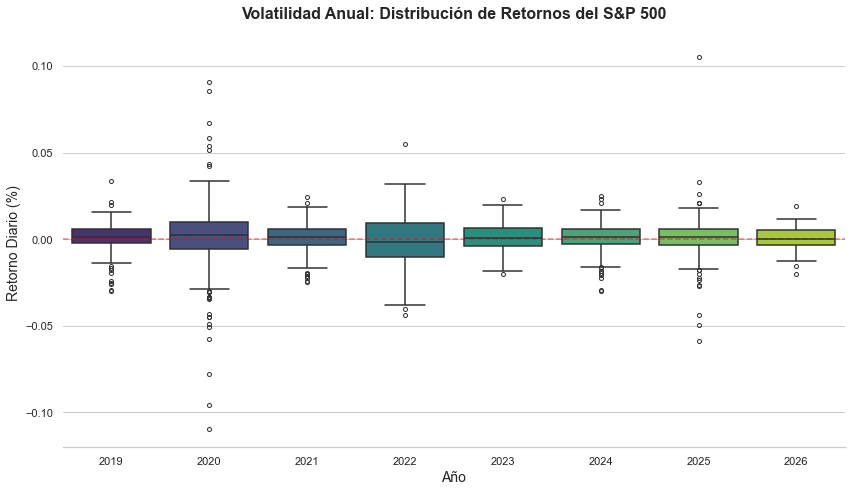

In [ ]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(x = 'Year', y = 'SPY', data = df_retornos.reset_index(), 
                 palette = 'viridis', linewidth = 1.5, fliersize = 4)

plt.axhline(0, color = 'red', linestyle = '--', alpha = 0.5, label = 'Retorno Cero')
plt.title('Volatilidad Anual: Distribución de Retornos del S&P 500', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Año', fontsize = 14)
plt.ylabel('Retorno Diario (%)', fontsize = 14)
sns.despine(left = True)

plt.tight_layout()
plt.show()

**Gráfico 3**

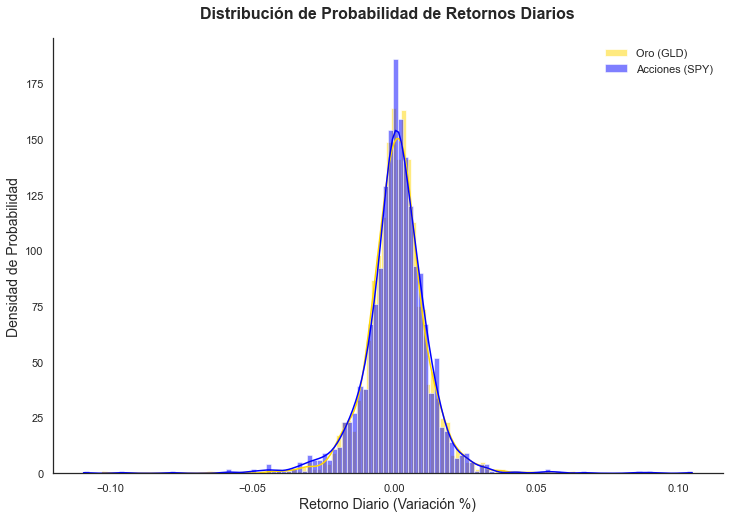

In [26]:
plt.figure(figsize=(12,8))

sns.histplot(df_retornos['GLD'], kde = True, color = 'gold', label = 'Oro (GLD)')
sns.histplot(df_retornos['SPY'], kde = True, color = 'blue', label = 'Acciones (SPY)', alpha = 0.5)

plt.title('Distribución de Probabilidad de Retornos Diarios', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Retorno Diario (Variación %)', fontsize = 14)
plt.ylabel('Densidad de Probabilidad', fontsize = 14)
plt.legend()
sns.despine()

plt.show()

**Gráfico 4**

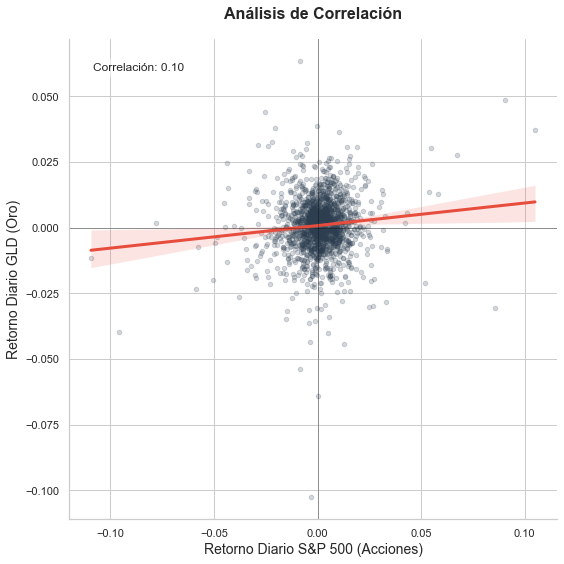

In [35]:
plt.figure(figsize = (8, 8))
sns.set_theme(style = "whitegrid")

# 'joint_kws' permite configurar los puntos y la línea por separado
ax = sns.regplot(x = 'SPY', y = 'GLD', data = df_retornos, 
                 scatter_kws = {'alpha':0.2, 'color':'#2c3e50', 's':20}, 
                 line_kws = {'color':'#e74c3c', 'linewidth':3},
                 marker = 'o')

plt.axhline(0, color='black', linewidth=1, alpha=0.3)
plt.axvline(0, color='black', linewidth=1, alpha=0.3)

# Calcula la correlación para mostrarla en el gráfico
corr_val = df_retornos['SPY'].corr(df_retornos['GLD'])

plt.title(f'Análisis de Correlación', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Retorno Diario S&P 500 (Acciones)', fontsize = 14)
plt.ylabel('Retorno Diario GLD (Oro)', fontsize = 14)

plt.text(0.05, 0.95, f'Correlación: {corr_val:.2f}', transform=ax.transAxes, 
         fontsize = 12, verticalalignment = 'top', bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

sns.despine()
plt.tight_layout()
plt.show()